# Основные сведения о библиотеке OSMnx

## 📚 Общая информация

### 🔹 Что такое OSMnx? {.unnumbered}

**OSMNx** — это библиотека на языке **Python**, предназначенная для **загрузки, анализа и визуализации графов улично-дорожных сетей** из проекта [OpenStreetMap (OSM)](https://www.openstreetmap.org).
Помимо графов улично-дорожных сетей позволяет работать со зданиями, границами районов и другими пространственными объектами.

---

### 🔹 Основные возможности: {.unnumbered}

| Возможность | Описание |
|------------|----------|
| 🗺️ Загрузка графов улиц | Можно загрузить дорожную сеть любого города или района |
| 🧭 Поддержка разных типов дорог | Автомобильные, пешеходные, велосипедные и другие сети |
| 🏙️ Работа с объектами | Загрузка зданий, границ населенных пунктов, водоёмов и других объектов |
| 📐 Анализ графов | Поиск кратчайших путей, расчёт плотности сети, анализ топологии |
| 🎨 Визуализация | Отрисовка карт и маршрутов с помощью Matplotlib |
| 🌐 Интеграция с другими библиотеками | Совместимость с NetworkX, GeoPandas, Folium, Contextily и др. |
| 💾 Сохранение данных | Графы можно сохранить в форматах: GraphML, Shapefile, GeoJSON |

---

### 🔹 Примеры использования: {.unnumbered}

- Загрузка и анализ улично-дорожных сетей
- Анализ ориентации улиц населенных пунктов
- Расчёт маршрутов между точками
- Исследование доступности общественного транспорта
- Образование и научные исследования в области геоинформатики
- Создание прототипов приложений для навигации и логистики

---

### 🔹 Основные функции: {.unnumbered}

| Функция | Назначение |
|--------|-----------|
| `ox.graph_from_place()` | Загружает граф улиц по названию места |
| `ox.graph_from_bbox()` | Загружает граф по координатам прямоугольной области |
| `ox.geometries_from_place()` | Загружает объекты (здания, парки и др.) |
| `ox.plot_graph()` | Рисует граф на карте |
| `ox.shortest_path()` | Находит кратчайший путь между узлами графа |
| `ox.distance.nearest_nodes()` | Находит ближайшие узлы к заданным координатам |
| `ox.save_graphml()` / `ox.save_graph_geopackage()` | Сохраняет граф в файл **GraphML** или **geopackage** |

---

### 🔹 Техническая информация: {.unnumbered}

| Характеристика | Описание |
|----------------|----------|
| Язык программирования | Python |
| Лицензия | MIT License (открытый исходный код) |
| Автор | Geoff Boeing ([https://geoffboeing.com](https://geoffboeing.com)) [@boeing_osmnx_2017; @boeing_resilient_2024] |
| Документация | [https://osmnx.readthedocs.io](https://osmnx.readthedocs.io) |
| Установка | `pip install osmnx` или `conda install -c conda-forge osmnx` |
| Зависимости | NetworkX, GeoPandas, Matplotlib, Requests и др. |

Напиши следующие примеры использования библиотеки osmnx:

- Загрузка графа дорог по названию города
- Загрузка полигона границ
- Загрузка графа дорог в пределах полигона границ
- Загрузка графа дорог в пределах полигона границ с буфером 1000 м
- Установка скоростей следования для дорог
- Расчет кратчайшего маршрута и времени следования между разными точками
- Загрузка данных о зданиях в пределах полигона границ населенного пункта
- Сопоставление зданий с ближайшими к ним вершинами графа дорожной сети
- Сохранение графа дорог в GraphML и geopackage
- Загрузка графа дорог из GraphML
- Сохранение полигона границ и данных о зданиях в файлы geopackage

В качестве исходного города используй "Сосновоборск, Красноярский край, Россия".

Каждый пример должен заканчиваться изображением графа с результатами кода из примера.

## Основные примеры использования библиотеки osmnx

### Загрузка графа дорог по названию города {.unnumbered}

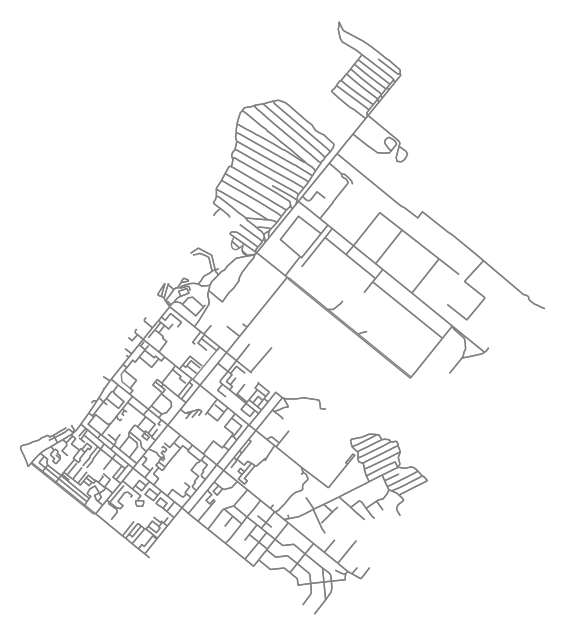

In [ ]:
import osmnx as ox
ox.settings.default_access = ''

# Загружаем дорожный граф по названию населенного пункта
G = ox.graph_from_place("Сосновоборск, Красноярский край, Россия", network_type="drive_service")

# Визуализируем граф
fig, ax = ox.plot_graph(G, node_size=0, edge_color='gray', bgcolor='white')

:::{.callout-note}

По умолчанию osmnx фильтрует дороги с пометкой `private` (частные). Для подразделений пожарной охраны это несущественно, т.к. они могут следовать в том числе и по частной территории. Поэтому при выгрузке ГДС рекомендуется использовать код:

    ox.settings.default_access = ''

:::

### Загрузка полигона границ населенного пункта {.unnumbered}

Text(0.5, 1.0, 'Границы Сосновоборска')

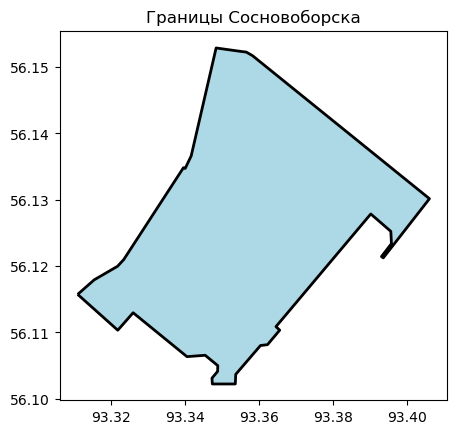

In [54]:
# Загружаем полигон границы Сосновоборска
boundary = ox.geocode_to_gdf("Сосновоборск, Красноярский край, Россия")

# Визуализируем полигон
ax = boundary.plot(facecolor='lightblue', edgecolor='black', linewidth=2)
ax.set_title("Границы Сосновоборска")

### Загрузка графа дорог в пределах полигона границ {.unnumbered}

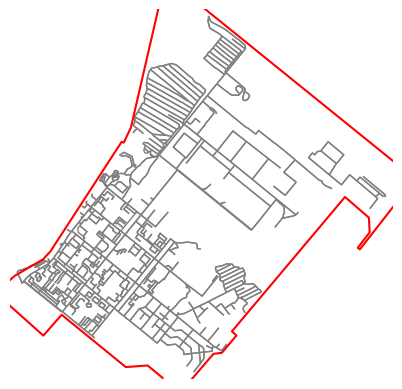

In [55]:
import matplotlib.pyplot as plt

# Используем ранее загруженный полигон для фильтрации графа
G = ox.graph_from_polygon(boundary.geometry.iloc[0], network_type="drive_service", retain_all=True)

# Визуализируем
ax = boundary.boundary.plot(color='r')
ox.plot_graph(G, ax=ax, node_size=0, edge_color='grey', bgcolor='white');

### Загрузка графа дорог в пределах полигона с буфером 1000 м {.unnumbered}

<Axes: >

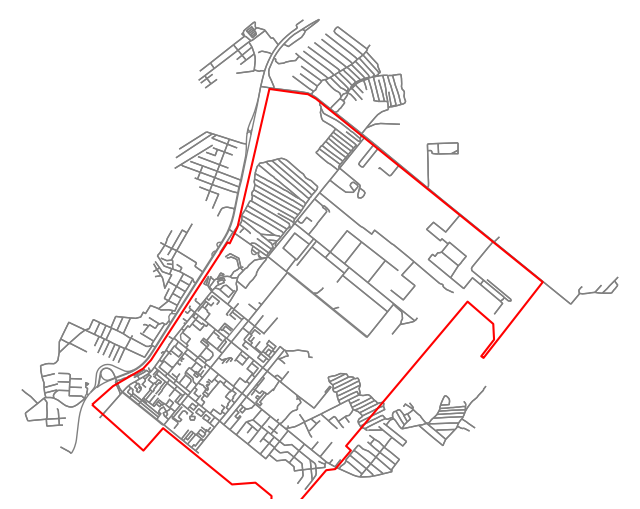

In [56]:
# Создаем буфер вокруг полигона (в метрах)
buffered_polygon = ox.projection.project_gdf(boundary).copy()
buffered_polygon.geometry = buffered_polygon.geometry.buffer(1000)
buffered_polygon = ox.projection.project_gdf(buffered_polygon, to_latlong=True)
# buffered_polygon

# Загружаем граф с учетом буфера
G = ox.graph_from_polygon(buffered_polygon.union_all(), network_type="drive_service")

# Рисуем результат
fig, ax = ox.plot_graph(G, node_size=0, edge_color='grey', bgcolor='white', close=False, show=False)
boundary.boundary.plot(color='r', ax=ax)